In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/machine learning/praktikum/praktikum6"

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(path + "/data/winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [13]:
print('Ukuran dataset:', df.shape)
print('\nInfo dataset:')
print(df.info())
print('\nStatistik deskriptif:')
print(df.describe())
print('\nDistribusi nilai kualitas:')
print(df['quality'].value_counts().sort_index())

Ukuran dataset: (1599, 13)

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_label         1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB
None

Statistik deskriptif:
     

In [14]:
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Distribusi label pada data latih:')
print(pd.Series(y_train).value_counts())

Distribusi label pada data latih:
quality_label
0    1105
1     174
Name: count, dtype: int64


In [15]:
models = {
    'Linear SVM': SVC(kernel='linear', C=1, class_weight='balanced'),
    'RBF SVM': SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'Model: {name}')
    print('Akurasi:', acc)
    print(classification_report(y_test, y_pred, zero_division=0))
    print('-' * 50)

Model: Linear SVM
Akurasi: 0.809375
              precision    recall  f1-score   support

           0       0.97      0.81      0.88       277
           1       0.40      0.81      0.53        43

    accuracy                           0.81       320
   macro avg       0.68      0.81      0.71       320
weighted avg       0.89      0.81      0.83       320

--------------------------------------------------
Model: RBF SVM
Akurasi: 0.846875
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       277
           1       0.46      0.77      0.57        43

    accuracy                           0.85       320
   macro avg       0.71      0.81      0.74       320
weighted avg       0.89      0.85      0.86       320

--------------------------------------------------


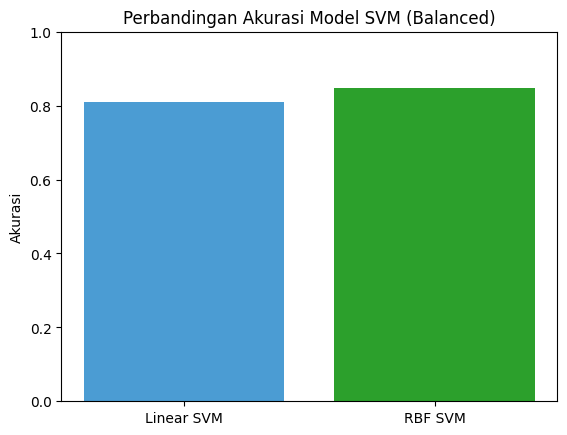

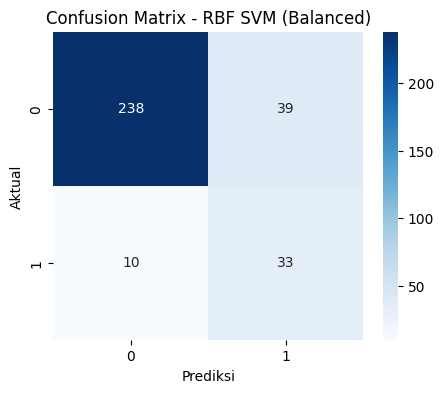

In [16]:
plt.bar(results.keys(), results.values(), color=['#4B9CD3','#2CA02C'])
plt.title('Perbandingan Akurasi Model SVM (Balanced)')
plt.ylabel('Akurasi')
plt.ylim(0, 1)
plt.show()

best_model = SVC(kernel='rbf', C=1, gamma='scale', class_weight='balanced')
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - RBF SVM (Balanced)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

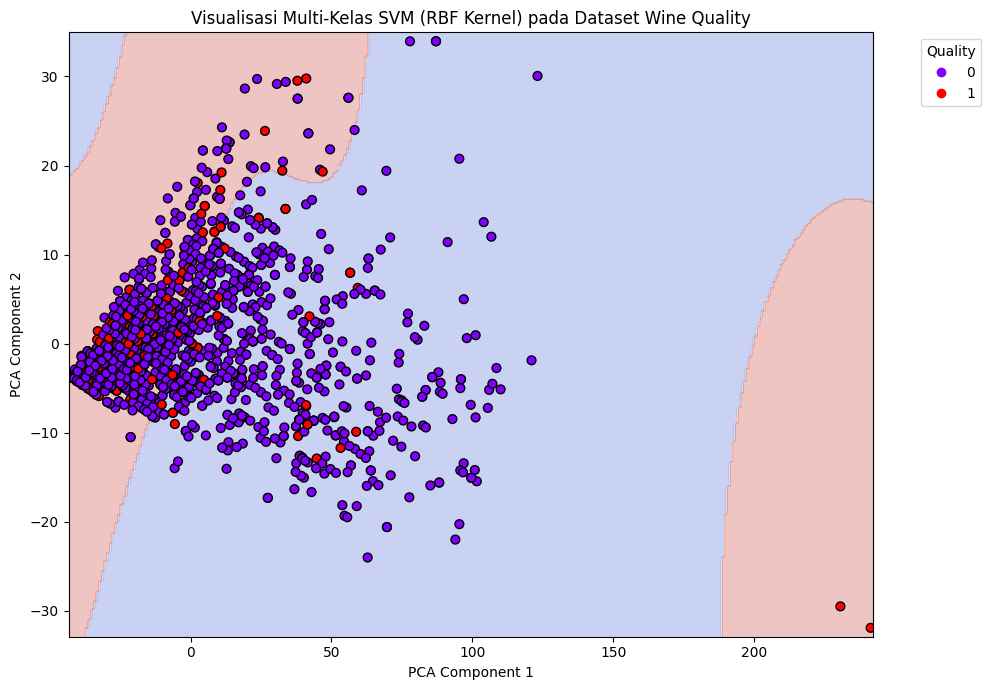

In [19]:
# Reduksi dimensi menggunakan PCA ke 2 komponen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Latih model SVM dengan kernel RBF (multi-kelas)
svm_vis = SVC(kernel='rbf', gamma='scale', class_weight='balanced')
svm_vis.fit(X_pca, y)

# Buat grid untuk menggambar decision boundary
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Prediksi untuk setiap titik grid
Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot hasil klasifikasi
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='rainbow', edgecolor='k', s=40)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Visualisasi Multi-Kelas SVM (RBF Kernel) pada Dataset Wine Quality')
plt.legend(*scatter.legend_elements(), title="Quality", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

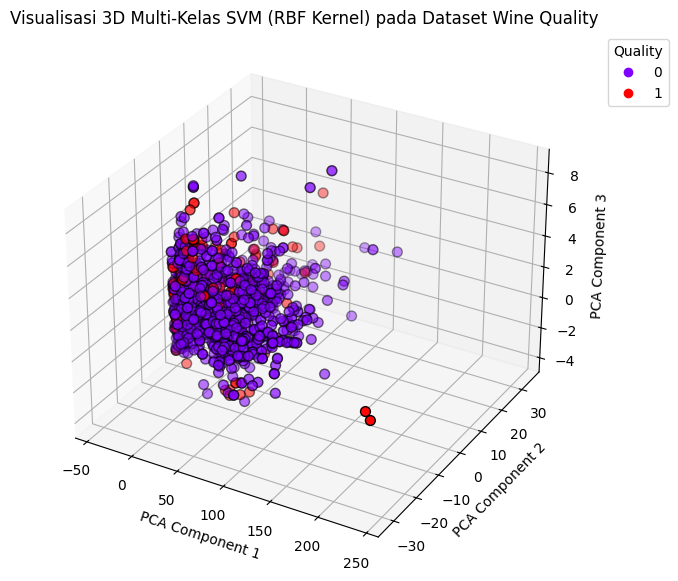

In [20]:
# Reduksi dimensi ke 3 komponen PCA
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X)

# Latih model SVM untuk data hasil PCA 3D
svm_3d = SVC(kernel='rbf', gamma='scale', class_weight='balanced')
svm_3d.fit(X_pca_3d, y)

# Plot 3D hasil klasifikasi
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Titik data dengan warna berdasarkan kualitas wine
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=y, cmap='rainbow', edgecolor='k', s=50)

# Label dan judul
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('Visualisasi 3D Multi-Kelas SVM (RBF Kernel) pada Dataset Wine Quality')

# Tambahkan legenda di luar plot
legend = ax.legend(*scatter.legend_elements(), title="Quality", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()